<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">1. Import Libraries</h3>
</div>


In [2076]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2077]:
import warnings
warnings.filterwarnings('ignore')

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">2. Import Dataset</h3>
</div>


In [2078]:
# Load the dataset
df = pd.read_csv('turnover.csv', encoding='ISO-8859-1')

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">3. Exploratory data analysis </h3>
</div>


In [2079]:
# View dimension of dataset
df.shape

(1129, 16)

In [2080]:
# Preview the dataset
df.head()

,stag,event,gender,age,industry,profession,traffic,coach,head_gender,greywage,way,extraversion,independ,selfcontrol,anxiety,novator
0,7.030801,1,m,35.0,Banks,HR,rabrecNErab,no,f,white,bus,6.2,4.1,5.7,7.1,8.3
1,22.965092,1,m,33.0,Banks,HR,empjs,no,m,white,bus,6.2,4.1,5.7,7.1,8.3
2,15.934292,1,f,35.0,PowerGeneration,HR,rabrecNErab,no,m,white,bus,6.2,6.2,2.6,4.8,8.3
3,15.934292,1,f,35.0,PowerGeneration,HR,rabrecNErab,no,m,white,bus,5.4,7.6,4.9,2.5,6.7
4,8.410678,1,m,32.0,Retail,Commercial,youjs,yes,f,white,bus,3.0,4.1,8.0,7.1,3.7


In [2081]:
# View column names
col_names = df.columns
print(col_names)

Index(['stag', 'event', 'gender', 'age', 'industry', 'profession', 'traffic',
       'coach', 'head_gender', 'greywage', 'way', 'extraversion', 'independ',
       'selfcontrol', 'anxiety', 'novator'],
      dtype='object')


In [2082]:
# View summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1129 entries, 0 to 1128
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   stag          1129 non-null   float64
 1   event         1129 non-null   int64  
 2   gender        1129 non-null   object 
 3   age           1129 non-null   float64
 4   industry      1129 non-null   object 
 5   profession    1129 non-null   object 
 6   traffic       1129 non-null   object 
 7   coach         1129 non-null   object 
 8   head_gender   1129 non-null   object 
 9   greywage      1129 non-null   object 
 10  way           1129 non-null   object 
 11  extraversion  1129 non-null   float64
 12  independ      1129 non-null   float64
 13  selfcontrol   1129 non-null   float64
 14  anxiety       1129 non-null   float64
 15  novator       1129 non-null   float64
dtypes: float64(7), int64(1), object(8)
memory usage: 141.3+ KB


In [2083]:
# find categorical variables
categorical = [var for var in df.columns if df[var].dtype == 'O']
print('There are {} categorical variables\n'.format(len(categorical)))
print('The categorical variables are :', categorical)

There are 8 categorical variables

The categorical variables are : ['gender', 'industry', 'profession', 'traffic', 'coach', 'head_gender', 'greywage', 'way']


In [2084]:
# view the categorical variables
df[categorical].head()

,gender,industry,profession,traffic,coach,head_gender,greywage,way
0,m,Banks,HR,rabrecNErab,no,f,white,bus
1,m,Banks,HR,empjs,no,m,white,bus
2,f,PowerGeneration,HR,rabrecNErab,no,m,white,bus
3,f,PowerGeneration,HR,rabrecNErab,no,m,white,bus
4,m,Retail,Commercial,youjs,yes,f,white,bus


In [2085]:
# check missing values in categorical variables
df[categorical].isnull().sum()

gender         0
industry       0
profession     0
traffic        0
coach          0
head_gender    0
greywage       0
way            0
dtype: int64

In [2086]:
# view frequency of categorical variables
for var in categorical:
    print(df[var].value_counts())

gender
f    853
m    276
Name: count, dtype: int64
industry
Retail             289
manufacture        145
IT                 122
Banks              114
etc                 94
Consult             74
State               55
Building            41
PowerGeneration     38
transport           38
Telecom             36
Mining              24
Pharma              20
Agriculture         15
RealEstate          13
 HoReCa             11
Name: count, dtype: int64
profession
HR                     757
IT                      74
Sales                   66
etc                     37
Marketing               31
BusinessDevelopment     27
Consult                 25
Commercial              23
manage                  22
Finanñe                 17
Engineer                15
Teaching                12
Accounting              10
Law                      7
PR                       6
Name: count, dtype: int64
traffic
youjs          318
empjs          248
rabrecNErab    211
friends        118
referal         95
K

In [2087]:
# view frequency distribution of categorical variables
for var in categorical:
    print(df[var].value_counts() / float(len(df)))

gender
f    0.755536
m    0.244464
Name: count, dtype: float64
industry
Retail             0.255979
manufacture        0.128432
IT                 0.108060
Banks              0.100974
etc                0.083260
Consult            0.065545
State              0.048716
Building           0.036315
PowerGeneration    0.033658
transport          0.033658
Telecom            0.031887
Mining             0.021258
Pharma             0.017715
Agriculture        0.013286
RealEstate         0.011515
 HoReCa            0.009743
Name: count, dtype: float64
profession
HR                     0.670505
IT                     0.065545
Sales                  0.058459
etc                    0.032772
Marketing              0.027458
BusinessDevelopment    0.023915
Consult                0.022143
Commercial             0.020372
manage                 0.019486
Finanñe                0.015058
Engineer               0.013286
Teaching               0.010629
Accounting             0.008857
Law                    0.

In [2088]:
# check for cardinality in categorical variables
for var in categorical:
    print(var, ' contains ', len(df[var].unique()), ' labels')

gender  contains  2  labels
industry  contains  16  labels
profession  contains  15  labels
traffic  contains  8  labels
coach  contains  3  labels
head_gender  contains  2  labels
greywage  contains  2  labels
way  contains  3  labels


<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">3.1. Explore problems within categorical variables</h4>
    </div>


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.1. Explore Gender Variable
</h5>
</div>


In [2089]:
# print number of labels in Location variable
print('Gender contains', len(df.gender.unique()), 'labels')

Gender contains 2 labels


In [2090]:
# check labels in gender variable
df.gender.unique()

array(['m', 'f'], dtype=object)

In [2091]:
# check frequency distribution of values in Location variable
df.gender.value_counts()

gender
f    853
m    276
Name: count, dtype: int64

In [2092]:
pd.get_dummies(df.gender, drop_first=True).head()

,m
0,True
1,True
2,False
3,False
4,True


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.2. Explore industry Variable
</h5>
</div>



In [2093]:
print('Industry contains', len(df.industry.unique()), 'labels')

Industry contains 16 labels


In [2094]:
df.industry.unique()

array(['Banks', 'PowerGeneration', 'Retail', 'manufacture', 'Consult',
       'State', 'etc', 'Building', 'IT', ' HoReCa', 'Telecom', 'Pharma',
       'Mining', 'transport', 'Agriculture', 'RealEstate'], dtype=object)

In [2095]:
df.industry.value_counts()

industry
Retail             289
manufacture        145
IT                 122
Banks              114
etc                 94
Consult             74
State               55
Building            41
PowerGeneration     38
transport           38
Telecom             36
Mining              24
Pharma              20
Agriculture         15
RealEstate          13
 HoReCa             11
Name: count, dtype: int64

In [2096]:
pd.get_dummies(df.industry, drop_first=True, dummy_na=True).head()

,Agriculture,Banks,Building,Consult,IT,Mining,Pharma,PowerGeneration,RealEstate,Retail,State,Telecom,etc,manufacture,transport,NaN
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.3. Explore profession Variable</h5>
</div>


In [2097]:
print('Profession contains', len(df.profession.unique()), 'labels')

Profession contains 15 labels


In [2098]:
df.profession.unique()

array(['HR', 'Commercial', 'Marketing', 'etc', 'Sales',
       'BusinessDevelopment', 'Finanñe', 'Teaching', 'manage', 'IT',
       'Law', 'Consult', 'Engineer', 'PR', 'Accounting'], dtype=object)

In [2099]:
df.profession.value_counts()

profession
HR                     757
IT                      74
Sales                   66
etc                     37
Marketing               31
BusinessDevelopment     27
Consult                 25
Commercial              23
manage                  22
Finanñe                 17
Engineer                15
Teaching                12
Accounting              10
Law                      7
PR                       6
Name: count, dtype: int64

In [2100]:
pd.get_dummies(df.profession, drop_first=True, dummy_na=True).head()

,BusinessDevelopment,Commercial,Consult,Engineer,Finanñe,HR,IT,Law,Marketing,PR,Sales,Teaching,etc,manage,NaN
0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.4. Explore traffic Variable</h5>
</div>


In [2101]:
print('Traffic contains', len(df.traffic.unique()), 'labels')

Traffic contains 8 labels


In [2102]:
df.traffic.unique()

array(['rabrecNErab', 'empjs', 'youjs', 'referal', 'advert', 'KA',
       'recNErab', 'friends'], dtype=object)

In [2103]:
df.traffic.value_counts()

traffic
youjs          318
empjs          248
rabrecNErab    211
friends        118
referal         95
KA              67
recNErab        39
advert          33
Name: count, dtype: int64

In [2104]:
pd.get_dummies(df.traffic, drop_first=True, dummy_na=True).head()

,advert,empjs,friends,rabrecNErab,recNErab,referal,youjs,NaN
0,False,False,False,True,False,False,False,False
1,False,True,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,True,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.5. Explore coach Variable</h5>
</div>


In [2105]:
print('Coach contains', len(df.coach.unique()), 'labels')

Coach contains 3 labels


In [2106]:
df.coach.unique()

array(['no', 'yes', 'my head'], dtype=object)

In [2107]:
df.coach.value_counts()

coach
no         683
my head    314
yes        132
Name: count, dtype: int64

In [2108]:
pd.get_dummies(df.coach, drop_first=True, dummy_na=True).head()

,no,yes,NaN
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,False,True,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.6. Explore head gender Variable</h5>
</div>


In [2109]:
print('Head gender contains', len(df.head_gender.unique()), 'labels')

Head gender contains 2 labels


In [2110]:
df.head_gender.unique()

array(['f', 'm'], dtype=object)

In [2111]:
df.head_gender.value_counts()

head_gender
m    584
f    545
Name: count, dtype: int64

In [2112]:
pd.get_dummies(df.head_gender, drop_first=True, dummy_na=True).head()

,m,NaN
0,False,False
1,True,False
2,True,False
3,True,False
4,False,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.7. Explore grey wage Variable</h5>
</div>


In [2113]:
print('Grey wage contains', len(df.greywage.unique()), 'labels')

Grey wage contains 2 labels


In [2114]:
df.greywage.unique()

array(['white', 'grey'], dtype=object)

In [2115]:
df.greywage.value_counts()

greywage
white    1002
grey      127
Name: count, dtype: int64

In [2116]:
pd.get_dummies(df.greywage, drop_first=True, dummy_na=True).head()

,white,NaN
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.8. Explore way Variable</h5>
</div>



In [2117]:
print('Way contains', len(df.way.unique()), 'labels')

Way contains 3 labels


In [2118]:
df.way.unique()

array(['bus', 'car', 'foot'], dtype=object)

In [2119]:
df.way.value_counts()

way
bus     681
car     331
foot    117
Name: count, dtype: int64

In [2120]:
pd.get_dummies(df.way, drop_first=True, dummy_na=True).head()

,car,foot,NaN
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False


<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">3.2. Explore Problem With Numerical Variables</h4>
    </div>


In [2121]:
# find numerical variables
target = 'event'
numerical = [var for var in df.columns if df[var].dtype != 'O' and var != target]
print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are :', numerical)

There are 7 numerical variables

The numerical variables are : ['stag', 'age', 'extraversion', 'independ', 'selfcontrol', 'anxiety', 'novator']


In [2122]:
# view the numerical variables
df[numerical].head()

,stag,age,extraversion,independ,selfcontrol,anxiety,novator
0,7.030801,35.0,6.2,4.1,5.7,7.1,8.3
1,22.965092,33.0,6.2,4.1,5.7,7.1,8.3
2,15.934292,35.0,6.2,6.2,2.6,4.8,8.3
3,15.934292,35.0,5.4,7.6,4.9,2.5,6.7
4,8.410678,32.0,3.0,4.1,8.0,7.1,3.7


In [2123]:
# check missing values in numerical variables
df[numerical].isnull().sum()

stag            0
age             0
extraversion    0
independ        0
selfcontrol     0
anxiety         0
novator         0
dtype: int64

In [2124]:
# view summary statistics in numerical variables
print(df[numerical].describe().round(2))

          stag      age  extraversion  independ  selfcontrol  anxiety  novator
count  1129.00  1129.00       1129.00   1129.00      1129.00  1129.00  1129.00
mean     36.63    31.07          5.59      5.48         5.60     5.67     5.88
std      34.10     7.00          1.85      1.70         1.98     1.71     1.90
min       0.39    18.00          1.00      1.00         1.00     1.70     1.00
25%      11.73    26.00          4.60      4.10         4.10     4.80     4.40
50%      24.34    30.00          5.40      5.50         5.70     5.60     6.00
75%      51.32    36.00          7.00      6.90         7.20     7.10     7.50
max     179.45    58.00         10.00     10.00        10.00    10.00    10.00


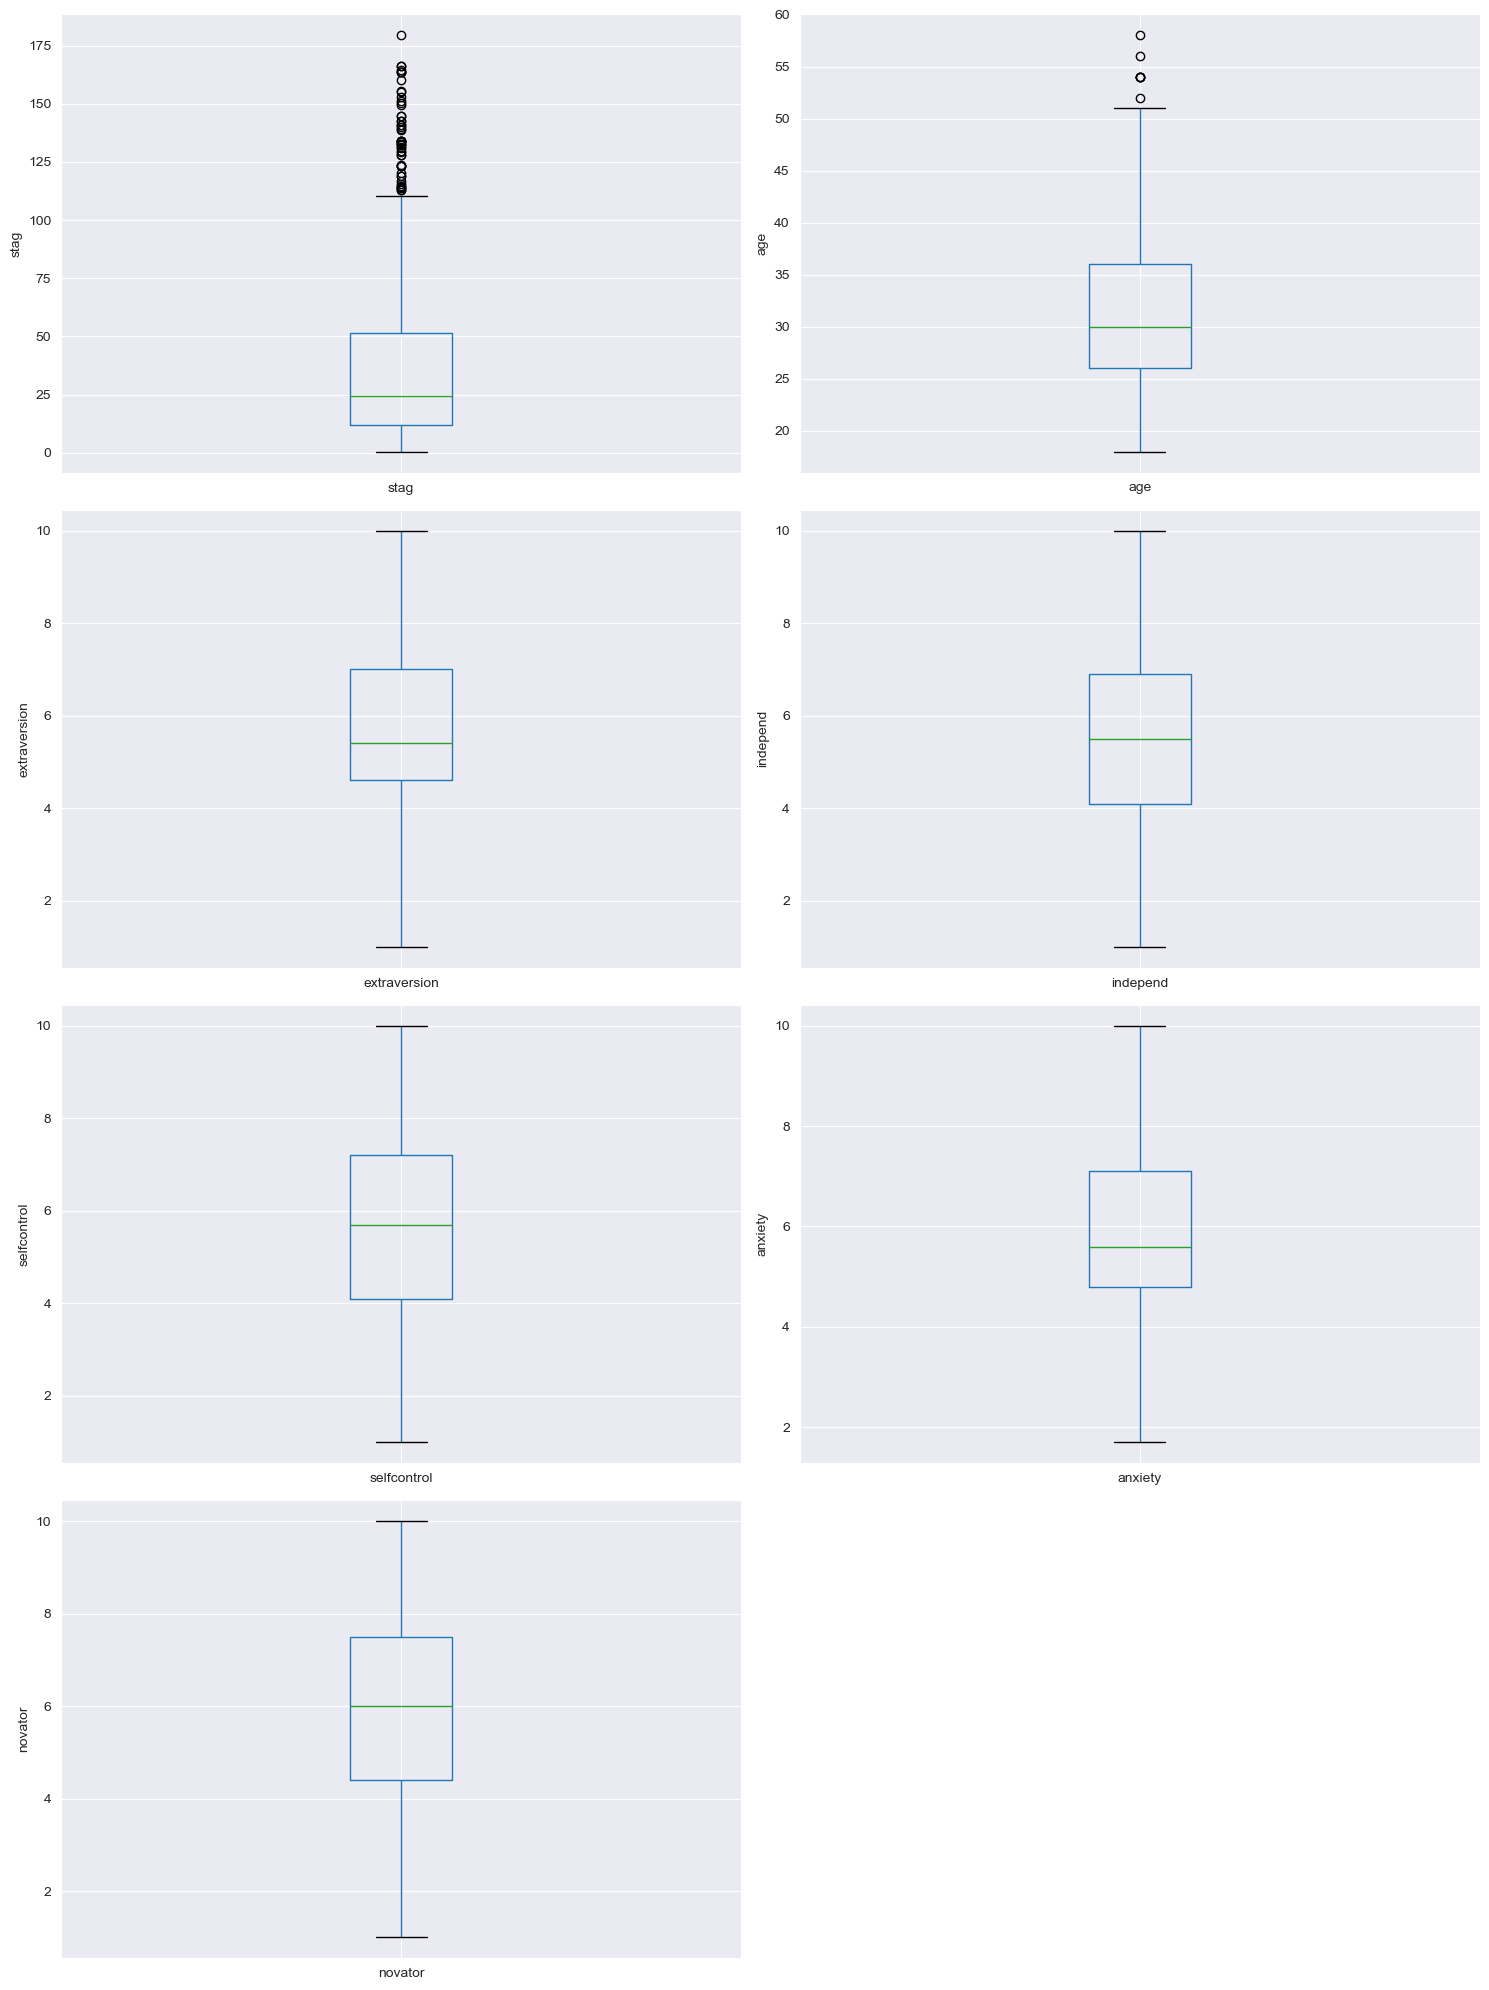

In [2125]:
# plot boxplot to identify outliers in numerical variables
# Create a figure with a specified size
plt.figure(figsize=(15, 20))

# List of columns to plot
columns = ['stag', 'age', 'extraversion', 'independ', 'selfcontrol', 'anxiety', 'novator']

# Loop through the columns and create a subplot for each
for i, column in enumerate(columns, 1):
    plt.subplot(4, 2, i)
    fig = df.boxplot(column=column)
    fig.set_title('')
    fig.set_ylabel(column)

# Show the plot
plt.tight_layout()
plt.show()

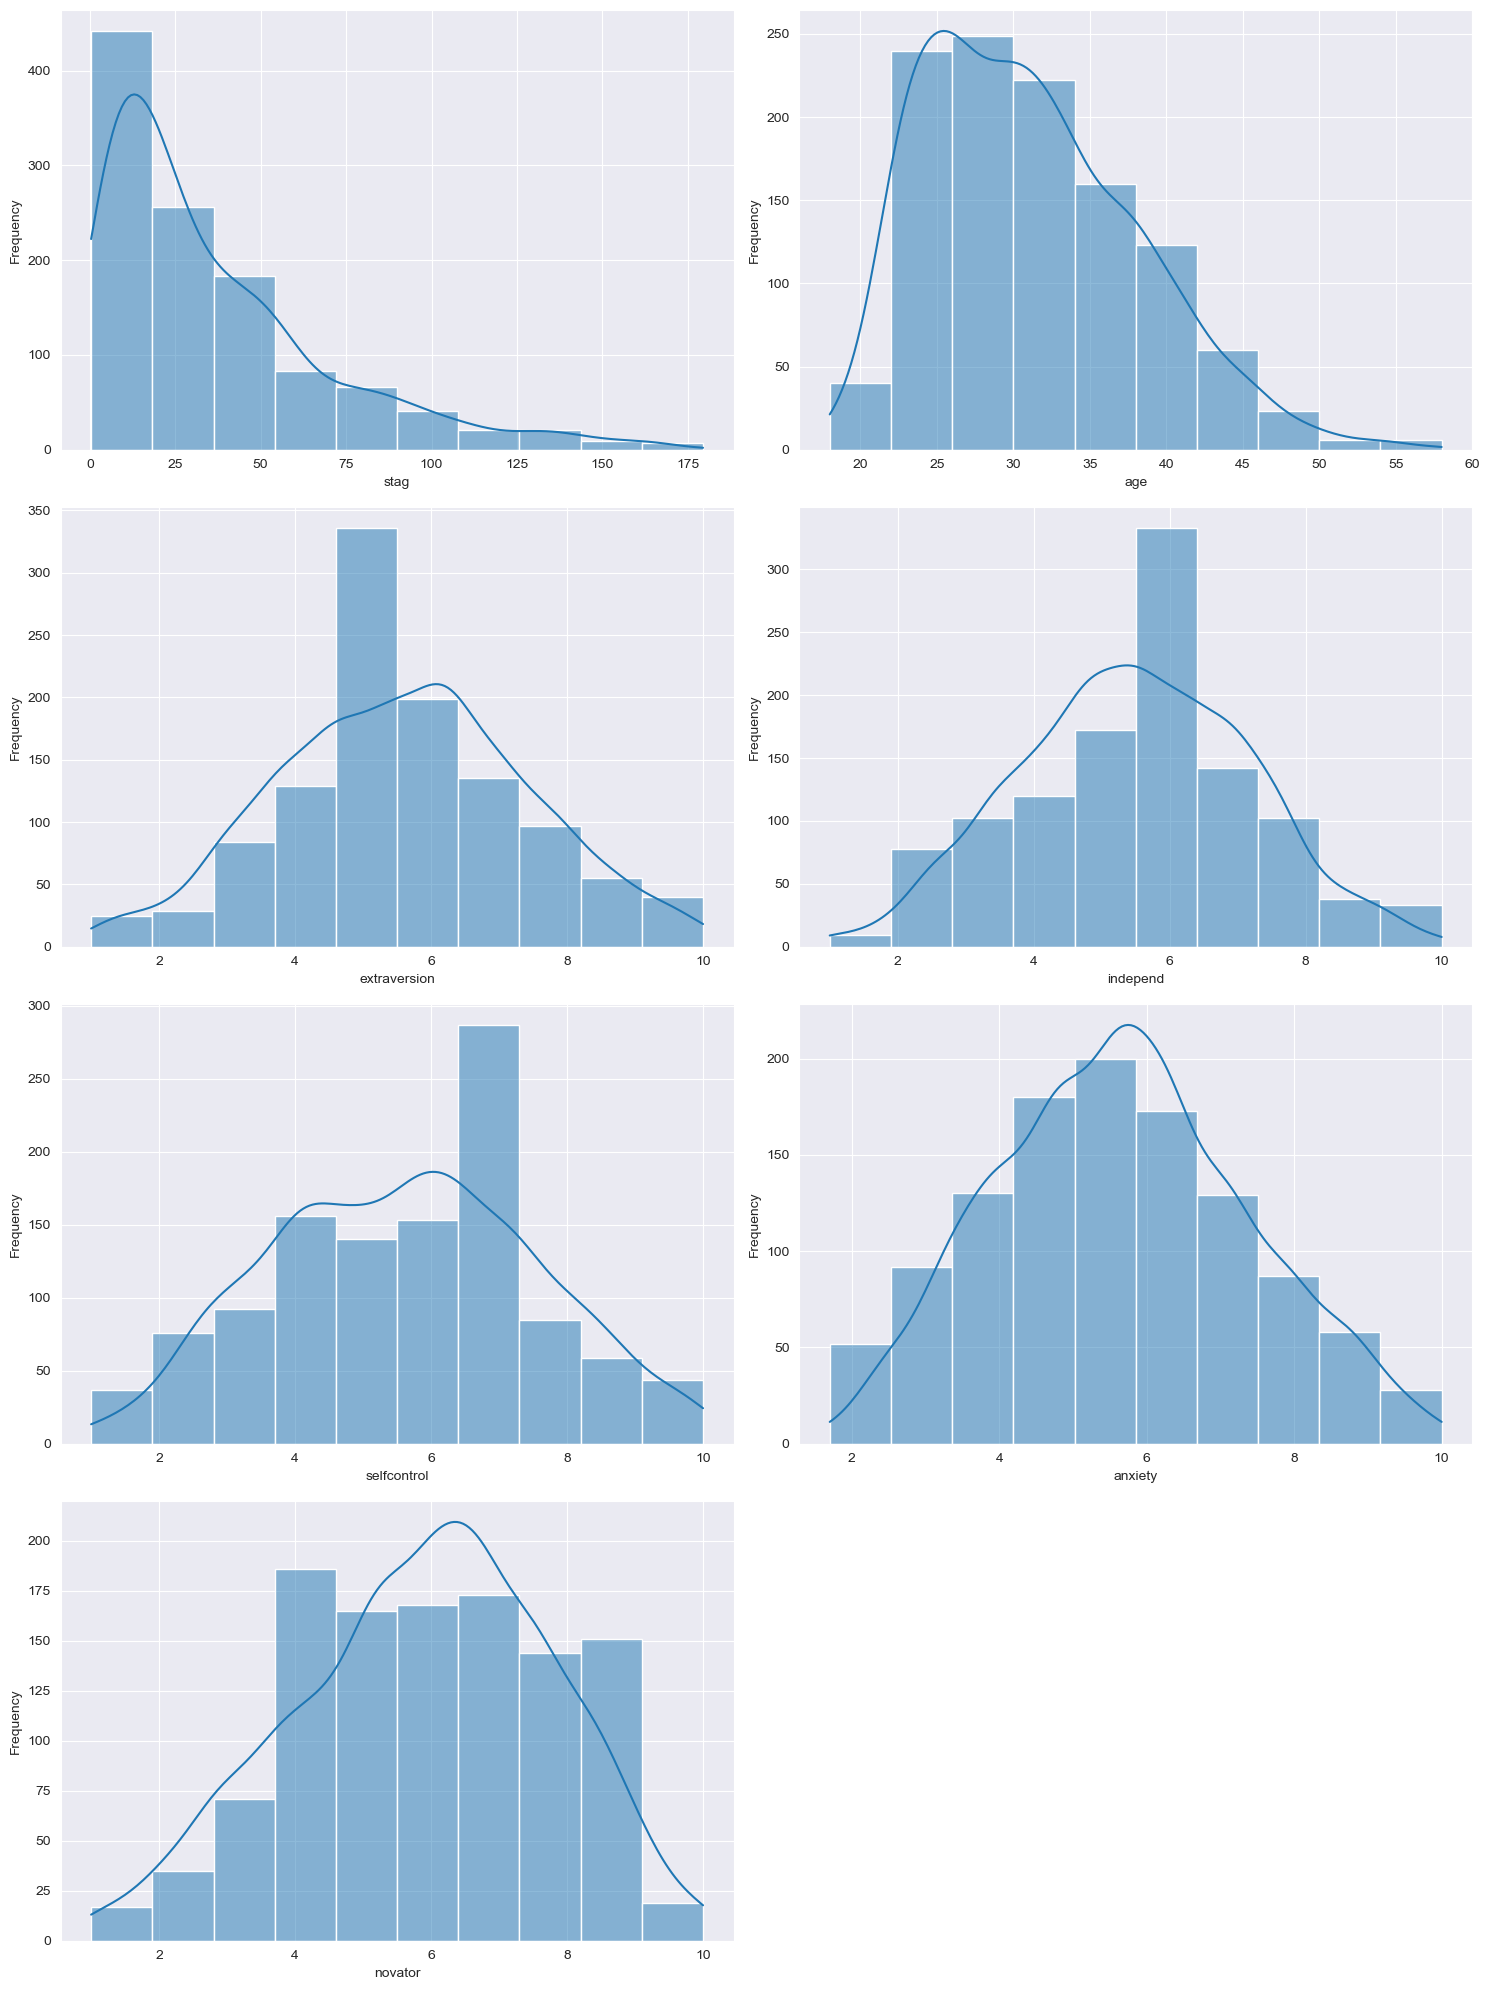

In [2126]:
plt.figure(figsize=(15, 20))
columns = ['stag', 'age', 'extraversion', 'independ', 'selfcontrol', 'anxiety', 'novator']

for i, column in enumerate(columns, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[column], bins=10, kde=True)
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [2127]:
# find outliers for Stag variable
IQR = df.stag.quantile(0.75) - df.stag.quantile(0.25)
Lower_fence = df.stag.quantile(0.25) - (IQR * 1.5)
Upper_fence = df.stag.quantile(0.75) + (IQR * 1.5)
print('Stag outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence,
                                                                               upperboundary=Upper_fence))

Stag outliers are values < -47.6550308 or > 110.70225872


In [2128]:
# find outliers for Age variable
IQR = df.age.quantile(0.75) - df.age.quantile(0.25)
Lower_fence = df.age.quantile(0.25) - (IQR * 3)
Upper_fence = df.age.quantile(0.75) + (IQR * 3)
print('Age outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence,
                                                                              upperboundary=Upper_fence))

Age outliers are values < -4.0 or > 66.0


### Compute the correlation matrix for only numerical columns

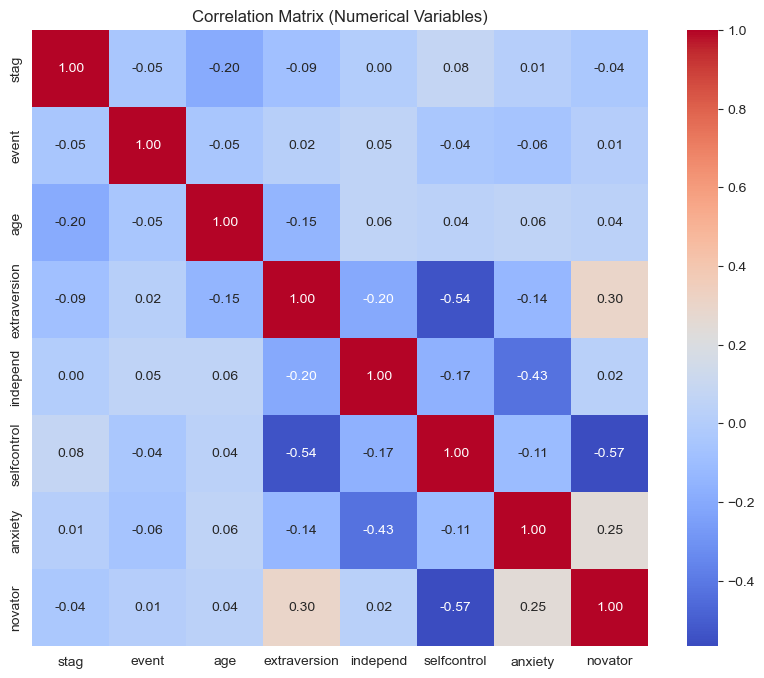

In [2129]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Create a heatmap to visualize the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, square=True)
plt.title('Correlation Matrix (Numerical Variables)')
plt.show()


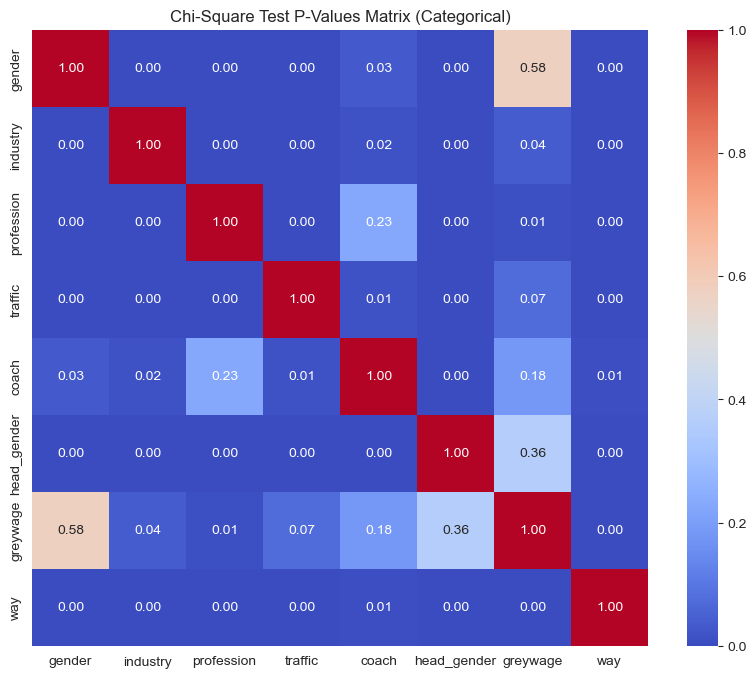

In [2130]:
from scipy.stats import chi2_contingency

# Function to apply chi-square test to categorical columns
def chi_square_test(df):
    categorical_columns = df.select_dtypes(include=['object']).columns
    p_values = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

    for col1 in categorical_columns:
        for col2 in categorical_columns:
            if col1 != col2:
                contingency_table = pd.crosstab(df[col1], df[col2])
                chi2, p, dof, expected = chi2_contingency(contingency_table)
                p_values.loc[col1, col2] = p
            else:
                p_values.loc[col1, col2] = 1.0  # p-value for a variable with itself is 1

    return p_values


# Get the p-values matrix
p_values_matrix = chi_square_test(df)

# Display the p-values matrix
plt.figure(figsize=(10, 8))
sns.heatmap(p_values_matrix.astype(float), annot=True, cmap='coolwarm', fmt='.2f', cbar=True, square=True)
plt.title("Chi-Square Test P-Values Matrix (Categorical)")
plt.show()


<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">4. Declare feature vector and target variable </h3>
</div>


In [2131]:
X = df.drop(['event'], axis=1)
y = df['event']

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">5. Split data into separate training and test set</h3>
</div>


In [2132]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2133]:
# check the shape of X_train and X_test
X_train.shape, X_test.shape

((903, 15), (226, 15))

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">6. Feature Engineering </h3>
</div>


In [2134]:
# check data types in X_train
X_train.dtypes

stag            float64
gender           object
age             float64
industry         object
profession       object
traffic          object
coach            object
head_gender      object
greywage         object
way              object
extraversion    float64
independ        float64
selfcontrol     float64
anxiety         float64
novator         float64
dtype: object

In [2135]:
# display categorical variables
categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']
categorical

['gender',
 'industry',
 'profession',
 'traffic',
 'coach',
 'head_gender',
 'greywage',
 'way']

In [2136]:
# display numerical variables
numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']
numerical

['stag',
 'age',
 'extraversion',
 'independ',
 'selfcontrol',
 'anxiety',
 'novator']

In [2137]:
df.columns.tolist()

['stag',
 'event',
 'gender',
 'age',
 'industry',
 'profession',
 'traffic',
 'coach',
 'head_gender',
 'greywage',
 'way',
 'extraversion',
 'independ',
 'selfcontrol',
 'anxiety',
 'novator']

In [2138]:
# Convert to lowercase and replace
X_train['coach'] = X_train['coach'].str.lower().replace('my head', 'yes')
X_test['coach'] = X_test['coach'].str.lower().replace('my head', 'yes')

In [2139]:
# Verify unique values in X_train and X_test before replacement
print("Unique values in X_train 'coach' column before replacement:")
print(X_train['coach'].unique())

print("\nUnique values in X_test 'coach' column before replacement:")
print(X_test['coach'].unique())


Unique values in X_train 'coach' column before replacement:
['no' 'yes']

Unique values in X_test 'coach' column before replacement:
['yes' 'no']


<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">6.1. Engineering missing values in numerical variables</h4>
    </div>


In [2140]:
# check missing values in numerical variables in X_train
X_train[numerical].isnull().sum()

stag            0
age             0
extraversion    0
independ        0
selfcontrol     0
anxiety         0
novator         0
dtype: int64

In [2141]:
# check missing values in numerical variables in X_test
X_test[numerical].isnull().sum()

stag            0
age             0
extraversion    0
independ        0
selfcontrol     0
anxiety         0
novator         0
dtype: int64

<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">6.2. Engineering missing values in categorical variables</h4>
    </div>


In [2142]:
# check missing values in X_train categorical variables
X_train[categorical].isnull().mean()

gender         0.0
industry       0.0
profession     0.0
traffic        0.0
coach          0.0
head_gender    0.0
greywage       0.0
way            0.0
dtype: float64

<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">6.3. Engineering outliers in numerical variables</h4>
    </div>


We have seen that the Stag, Age columns contain outliers. I will use top-coding approach to cap maximum values and remove outliers from the above variables.

In [2143]:
X_train[['stag', 'age']].max()


stag    179.449692
age      58.000000
dtype: float64

Stag outliers are values < -48.344969209999995 or > 111.85215606999999
Age outliers are values < 11.0 or > 51.0


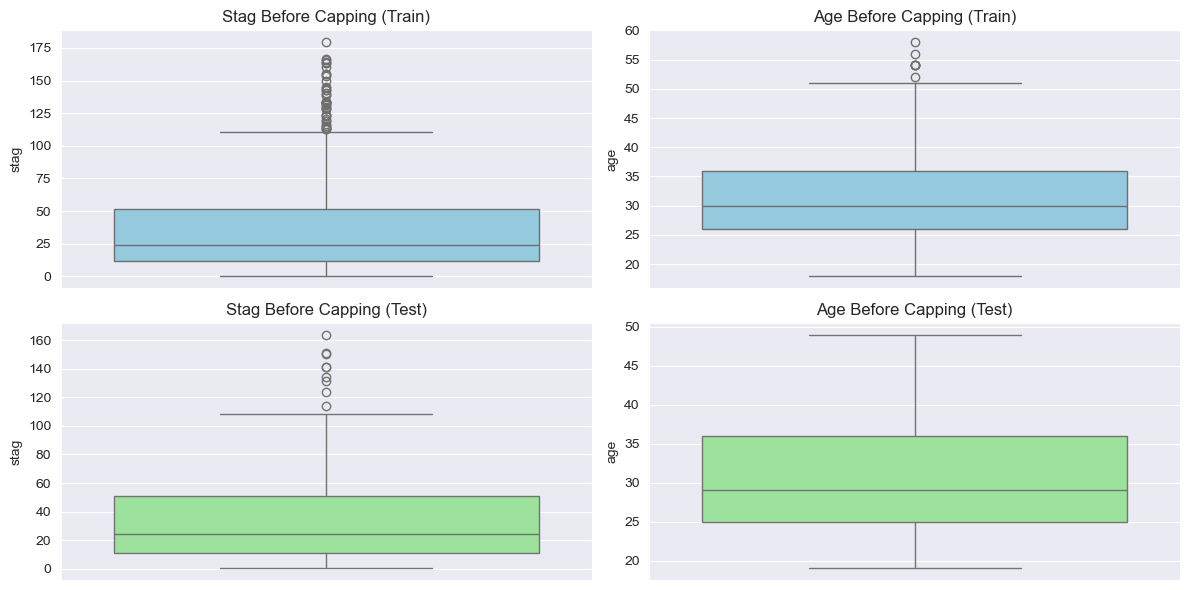

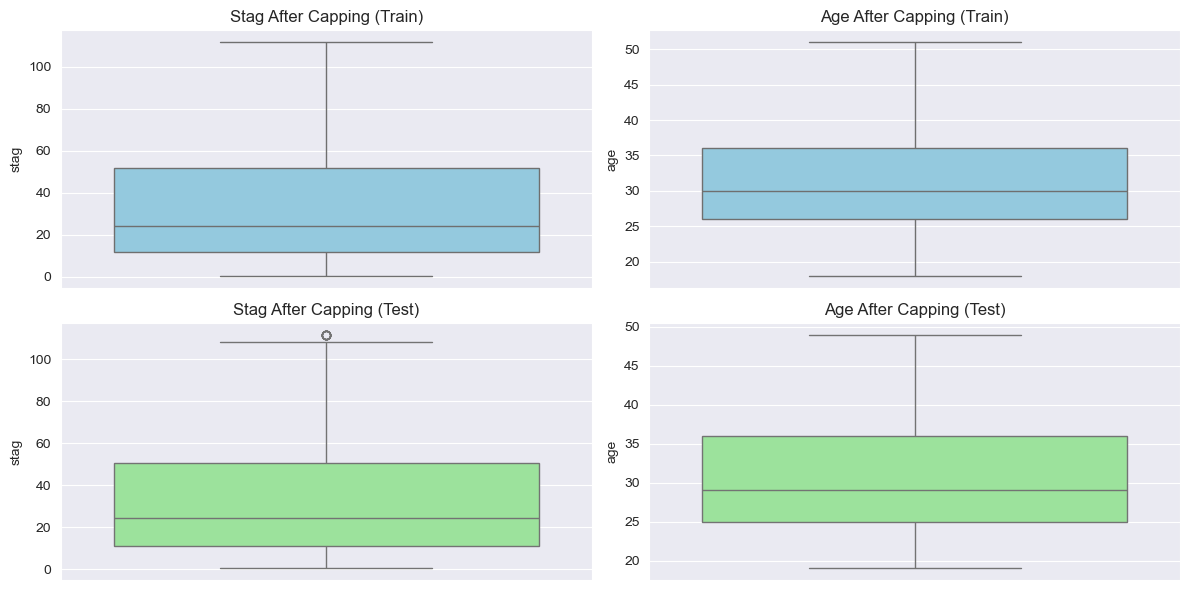

In [2144]:
def calculate_fences(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - (multiplier * IQR)
    upper_fence = Q3 + (multiplier * IQR)
    return lower_fence, upper_fence

# Calculate fences for 'stag' with multiplier 1.5
stag_lower_fence, stag_upper_fence = calculate_fences(X_train['stag'], multiplier=1.5)
print(f"Stag outliers are values < {stag_lower_fence} or > {stag_upper_fence}")

# Calculate fences for 'age' with multiplier 3
age_lower_fence, age_upper_fence = calculate_fences(X_train['age'], multiplier=1.5)
print(f"Age outliers are values < {age_lower_fence} or > {age_upper_fence}")

# Function to plot boxplots
def plot_boxplots(df_train, df_test, columns, titles):
    num_cols = len(columns)
    plt.figure(figsize=(12, 6))

    for i, col in enumerate(columns, 1):
        # Boxplot for Training Data
        plt.subplot(2, num_cols, i)
        sns.boxplot(y=df_train[col], color='skyblue')
        plt.title(f'{titles[i-1]} (Train)')

        # Boxplot for Test Data
        plt.subplot(2, num_cols, i + num_cols)
        sns.boxplot(y=df_test[col], color='lightgreen')
        plt.title(f'{titles[i-1]} (Test)')

    plt.tight_layout()
    plt.show()

# Columns to visualize
columns = ['stag', 'age']
titles_before = ['Stag Before Capping', 'Age Before Capping']

# Plot before capping
plot_boxplots(X_train, X_test, columns, titles_before)

# Function to cap outliers
def cap_outliers(df, column, lower, upper):
    return df[column].clip(lower=lower, upper=upper)

# Capping 'stag' in training and test sets
X_train['stag'] = cap_outliers(X_train, 'stag', stag_lower_fence, stag_upper_fence)
X_test['stag'] = cap_outliers(X_test, 'stag', stag_lower_fence, stag_upper_fence)

# Capping 'age' in training and test sets
X_train['age'] = cap_outliers(X_train, 'age', age_lower_fence, age_upper_fence)
X_test['age'] = cap_outliers(X_test, 'age', age_lower_fence, age_upper_fence)

# Titles after capping
titles_after = ['Stag After Capping', 'Age After Capping']

# Plot after capping
plot_boxplots(X_train, X_test, columns, titles_after)

In [2145]:
X_test[['stag', 'age']].max()

stag    111.852156
age      49.000000
dtype: float64

In [2146]:
X_train[['stag', 'age']].max()

stag    111.852156
age      51.000000
dtype: float64

In [2147]:
X_train[numerical].describe()

,stag,age,extraversion,independ,selfcontrol,anxiety,novator
count,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000
mean,35.743397,31.161244,5.581174,5.477076,5.601550,5.646179,5.882835
std,30.845326,6.951109,1.839225,1.685373,1.993514,1.681873,1.903592
min,0.394251,18.000000,1.000000,1.000000,1.000000,1.700000,1.000000
25%,11.728953,26.000000,4.600000,4.100000,4.100000,4.800000,4.400000
50%,24.344969,30.000000,5.400000,5.500000,5.700000,5.600000,6.000000
75%,51.778234,36.000000,7.000000,6.900000,7.200000,7.100000,7.500000
max,111.852156,51.000000,10.000000,10.000000,10.000000,10.000000,10.000000


We can now see that the outliers in stag, age columns are capped.

<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">6.4. Encode categorical variables</h4>
    </div>


In [2148]:
X_train[categorical].head()

,gender,industry,profession,traffic,coach,head_gender,greywage,way
490,f,Telecom,HR,referal,no,f,white,car
394,f,State,Teaching,recNErab,yes,f,grey,bus
596,f,Building,HR,empjs,yes,m,white,bus
887,f,Retail,HR,rabrecNErab,no,f,white,car
1103,f,manufacture,HR,friends,yes,f,white,bus


In [2149]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Assuming X_train and X_test are your training and testing DataFrames respectively

# 1. Define your binary and one-hot columns
binary_columns = ['gender', 'coach', 'head_gender', 'greywage']
onehot_columns = ['industry', 'profession', 'traffic', 'way']

# 2. Define explicit mappings for binary columns to ensure consistent encoding
binary_mappings = {
    'gender': {'m': 0, 'f': 1},
    'coach': {'no': 0, 'yes': 1},
    'head_gender': {'m': 0, 'f': 1},
    'greywage': {'grey': 0, 'white': 1}
}

# 3. Apply Label Encoding to binary columns in X_train
for col, mapping in binary_mappings.items():
    X_train[col] = X_train[col].map(mapping)

# 4. Apply the same Label Encoding to binary columns in X_test
for col, mapping in binary_mappings.items():
    X_test[col] = X_test[col].map(mapping)

# 5. Initialize the OneHotEncoder for multi-category columns
#    - drop='first' to avoid the dummy variable trap
#    - sparse_output=False to return a dense array
onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)

# 6. Fit the OneHotEncoder on X_train and transform both X_train and X_test
X_train_onehot = onehot_encoder.fit_transform(X_train[onehot_columns])
X_test_onehot = onehot_encoder.transform(X_test[onehot_columns])

# 7. Convert the One-Hot encoded arrays back to DataFrames with appropriate column names
onehot_feature_names = onehot_encoder.get_feature_names_out(onehot_columns)
X_train_onehot_df = pd.DataFrame(X_train_onehot, columns=onehot_feature_names, index=X_train.index)
X_test_onehot_df = pd.DataFrame(X_test_onehot, columns=onehot_feature_names, index=X_test.index)

# 8. Drop the original one-hot columns from X_train and X_test
X_train = X_train.drop(columns=onehot_columns)
X_test = X_test.drop(columns=onehot_columns)

# 9. Concatenate the One-Hot encoded columns back to X_train and X_test
X_train = pd.concat([X_train, X_train_onehot_df], axis=1)
X_test = pd.concat([X_test, X_test_onehot_df], axis=1)

# 10. (Optional) Reset index if necessary
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)

# Your data is now encoded with Label Encoding for binary columns and One-Hot Encoding for others


In [2150]:
X_train.head()

,stag,gender,age,coach,head_gender,greywage,extraversion,independ,selfcontrol,anxiety,...,profession_manage,traffic_advert,traffic_empjs,traffic_friends,traffic_rabrecNErab,traffic_recNErab,traffic_referal,traffic_youjs,way_car,way_foot
0,106.841889,1,22.0,0,1,1,7.0,3.4,4.1,6.3,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,111.852156,1,22.0,1,1,0,3.0,4.8,5.7,4.8,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2.365503,1,28.0,1,0,1,7.0,6.9,2.6,4.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5.355236,1,34.0,0,1,1,6.2,5.5,6.4,7.1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,16.657084,1,38.0,1,1,1,5.4,4.8,5.7,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2151]:
X_test.head()

,stag,gender,age,coach,head_gender,greywage,extraversion,independ,selfcontrol,anxiety,...,profession_manage,traffic_advert,traffic_empjs,traffic_friends,traffic_rabrecNErab,traffic_recNErab,traffic_referal,traffic_youjs,way_car,way_foot
0,79.540041,0,23.0,1,0,1,4.6,5.5,8.7,4.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,7.129363,1,21.0,1,0,1,5.4,6.9,7.2,2.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,6.669405,1,27.0,0,1,1,9.4,5.5,3.3,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,20.041068,1,25.0,1,1,1,9.4,3.4,1.8,8.7,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,3.811088,1,32.0,0,0,1,3.8,6.2,6.4,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [2152]:
X_train.shape, X_test.shape

((903, 49), (226, 49))

<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">6.5. Normalizing variables</h4>
    </div>


For stag variable - I will use log transformation to normalize the data as it is right skewed.

Skewness of stag before transformation: 1.07
Power transformed stag due to moderate skewness.
Skewness of age before transformation: 0.62
Power transformed age due to moderate skewness.
Skewness of anxiety before transformation: 0.18
No transformation applied to anxiety as skewness is within acceptable range.
Skewness of extraversion before transformation: -0.03
No transformation applied to extraversion as skewness is within acceptable range.


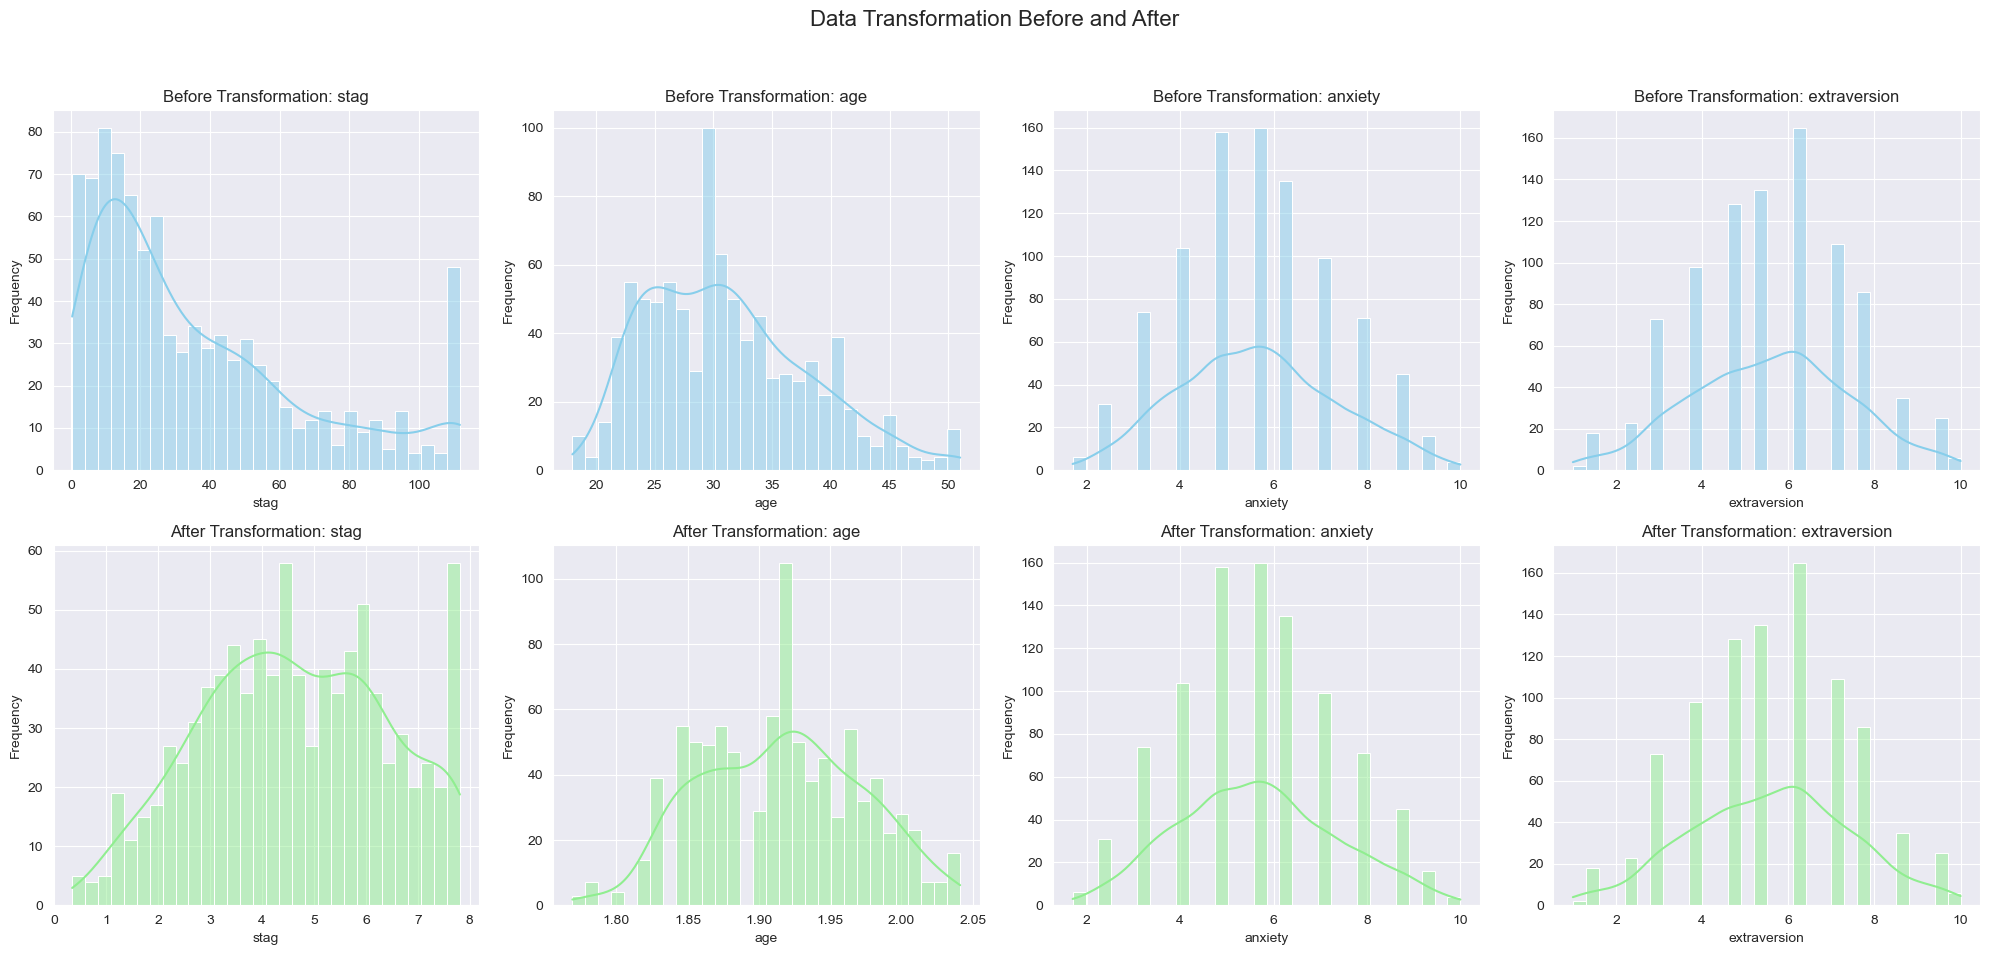

In [2153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, StandardScaler, MinMaxScaler

columns_to_transform = ['stag', 'age', 'anxiety', 'extraversion']  # Example list of columns

# Function to check if data has negative values
def has_negative(data):
    return (data < 0).any()

# Create subplots for before and after transformation
fig, axes = plt.subplots(2, len(columns_to_transform), figsize=(5 * len(columns_to_transform), 10))
fig.suptitle('Data Transformation Before and After', fontsize=16)

for i, column in enumerate(columns_to_transform):
    # Before Transformation: Plot histogram
    sns.histplot(X_train[column], kde=True, ax=axes[0, i], color='skyblue', bins=30)
    axes[0, i].set_title(f"Before Transformation: {column}")
    axes[0, i].set_xlabel(column)
    axes[0, i].set_ylabel('Frequency')

    # Calculate skewness
    skewness = X_train[column].skew()
    print(f"Skewness of {column} before transformation: {skewness:.2f}")

    # Initialize transformed columns
    X_train_transformed = X_train.copy()
    X_test_transformed = X_test.copy()

    # Transformation based on skewness
    if skewness > 2:
        if has_negative(X_train[column]):
            # Shift data if negative values exist
            shift = abs(X_train[column].min()) + 1
            X_train_transformed[column] = np.log1p(X_train[column] + shift)
            X_test_transformed[column] = np.log1p(X_test[column] + shift)
            print(f"Log-transformed {column} with a shift of {shift} due to high skewness and negative values.")
        else:
            X_train_transformed[column] = np.log1p(X_train[column])
            X_test_transformed[column] = np.log1p(X_test[column])
            print(f"Log-transformed {column} due to high skewness.")
    elif 0.5 < skewness <= 2:
        try:
            transformer = PowerTransformer(method='yeo-johnson', standardize=False)
            X_train_transformed[column] = transformer.fit_transform(X_train[[column]])
            X_test_transformed[column] = transformer.transform(X_test[[column]])
            print(f"Power transformed {column} due to moderate skewness.")
        except ValueError as e:
            print(f"Power transformation failed for {column}: {e}")
    else:
        print(f"No transformation applied to {column} as skewness is within acceptable range.")

    # After Transformation: Plot histogram
    sns.histplot(X_train_transformed[column], kde=True, ax=axes[1, i], color='lightgreen', bins=30)
    axes[1, i].set_title(f"After Transformation: {column}")
    axes[1, i].set_xlabel(column)
    axes[1, i].set_ylabel('Frequency')

    # Update the transformed data back to X_train and X_test
    X_train[column] = X_train_transformed[column]
    X_test[column] = X_test_transformed[column]

# Adjust layout and show the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">6.6. Feature Scaling</h4>
    </div>


In [2154]:
X_train.describe()

,stag,gender,age,coach,head_gender,greywage,extraversion,independ,selfcontrol,anxiety,...,profession_manage,traffic_advert,traffic_empjs,traffic_friends,traffic_rabrecNErab,traffic_recNErab,traffic_referal,traffic_youjs,way_car,way_foot
count,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000,...,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000,903.000000
mean,4.630973,0.761905,1.915987,0.385382,0.478405,0.890365,5.581174,5.477076,5.601550,5.646179,...,0.018826,0.027685,0.221484,0.102990,0.198228,0.036545,0.087486,0.266888,0.293466,0.100775
std,1.809133,0.426154,0.056582,0.486955,0.499810,0.312607,1.839225,1.685373,1.993514,1.681873,...,0.135986,0.164161,0.415476,0.304114,0.398886,0.187745,0.282703,0.442579,0.455603,0.301198
min,0.343495,0.000000,1.769146,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.303830,1.000000,1.876148,0.000000,0.000000,1.000000,4.600000,4.100000,4.100000,4.800000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.522298,1.000000,1.914442,0.000000,0.000000,1.000000,5.400000,5.500000,5.700000,5.600000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.015655,1.000000,1.960630,1.000000,1.000000,1.000000,7.000000,6.900000,7.200000,7.100000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,7.808572,1.000000,2.041169,1.000000,1.000000,1.000000,10.000000,10.000000,10.000000,10.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [2155]:
cols = X_train.columns

In [2156]:
print("Train columns:", X_train.columns)
print("Test columns:", X_test.columns)

Train columns: Index(['stag', 'gender', 'age', 'coach', 'head_gender', 'greywage',
       'extraversion', 'independ', 'selfcontrol', 'anxiety', 'novator',
       'industry_Agriculture', 'industry_Banks', 'industry_Building',
       'industry_Consult', 'industry_IT', 'industry_Mining', 'industry_Pharma',
       'industry_PowerGeneration', 'industry_RealEstate', 'industry_Retail',
       'industry_State', 'industry_Telecom', 'industry_etc',
       'industry_manufacture', 'industry_transport',
       'profession_BusinessDevelopment', 'profession_Commercial',
       'profession_Consult', 'profession_Engineer', 'profession_Finanñe',
       'profession_HR', 'profession_IT', 'profession_Law',
       'profession_Marketing', 'profession_PR', 'profession_Sales',
       'profession_Teaching', 'profession_etc', 'profession_manage',
       'traffic_advert', 'traffic_empjs', 'traffic_friends',
       'traffic_rabrecNErab', 'traffic_recNErab', 'traffic_referal',
       'traffic_youjs', 'way_car', 'wa

In [2157]:
from sklearn.preprocessing import StandardScaler

columns = X_train.columns

# Apply MinMaxScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert scaled data back to DataFrame and assign column names
X_train = pd.DataFrame(X_train, columns=columns)
X_test = pd.DataFrame(X_test, columns=columns)

In [2158]:
X_train.head()

,stag,gender,age,coach,head_gender,greywage,extraversion,independ,selfcontrol,anxiety,...,profession_manage,traffic_advert,traffic_empjs,traffic_friends,traffic_rabrecNErab,traffic_recNErab,traffic_referal,traffic_youjs,way_car,way_foot
0,1.693874,0.559017,-1.536495,-0.791850,1.044164,0.350905,0.771853,-1.233096,-0.753635,0.388961,...,-0.138518,-0.168742,-0.533381,-0.338843,-0.497230,-0.194759,3.229610,-0.603364,1.551627,-0.334767
1,1.757394,0.559017,-1.536495,1.262865,1.044164,-2.849774,-1.404181,-0.401959,0.049412,-0.503396,...,-0.138518,-0.168742,-0.533381,-0.338843,-0.497230,5.134553,-0.309635,-0.603364,-0.644485,-0.334767
2,-1.802859,0.559017,-0.349763,1.262865,-0.957704,0.350905,0.771853,0.844746,-1.506492,-0.979320,...,-0.138518,-0.168742,1.874833,-0.338843,-0.497230,-0.194759,-0.309635,-0.603364,-0.644485,-0.334767
3,-1.326961,0.559017,0.538824,-0.791850,1.044164,0.350905,0.336647,0.013609,0.400746,0.864885,...,-0.138518,-0.168742,-0.533381,-0.338843,2.011142,-0.194759,-0.309635,-0.603364,1.551627,-0.334767
4,-0.425169,0.559017,1.022004,1.262865,1.044164,0.350905,-0.098560,-0.401959,0.049412,-0.979320,...,-0.138518,-0.168742,-0.533381,2.951216,-0.497230,-0.194759,-0.309635,-0.603364,-0.644485,-0.334767


<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">8. Model training</h3>
</div>


In [2159]:
print("Class distribution in y_train:")
print(y_train.value_counts())

print("\nClass distribution in y_test:")
print(y_test.value_counts())


Class distribution in y_train:
event
1    453
0    450
Name: count, dtype: int64

Class distribution in y_test:
event
1    118
0    108
Name: count, dtype: int64


In [2160]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Step 1: Set up the Logistic Regression model
logreg = LogisticRegression(random_state=0)

# Step 2: Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['liblinear', 'saga', 'newton-cg', 'lbfgs'],  # Solvers to test
    'penalty': ['l1', 'l2', 'elasticnet'],  # Regularization type
    'max_iter': [100, 200, 500]  # Maximum number of iterations
}

# Step 3: Set up GridSearchCV with cross-validation
grid_search = GridSearchCV(estimator=logreg, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Step 4: Fit the grid search model on your training data
grid_search.fit(X_train, y_train)

# Step 5: Print the best parameters and best score
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-validation Score: {grid_search.best_score_}")

# Step 6: Use the best model to make predictions
best_logreg_model = grid_search.best_estimator_

# Step 7: Evaluate the model on the test set
y_pred = best_logreg_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy: {test_accuracy:.4f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Hyperparameters: {'C': 0.1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-validation Score: 0.594720687538367
Test Set Accuracy: 0.6858


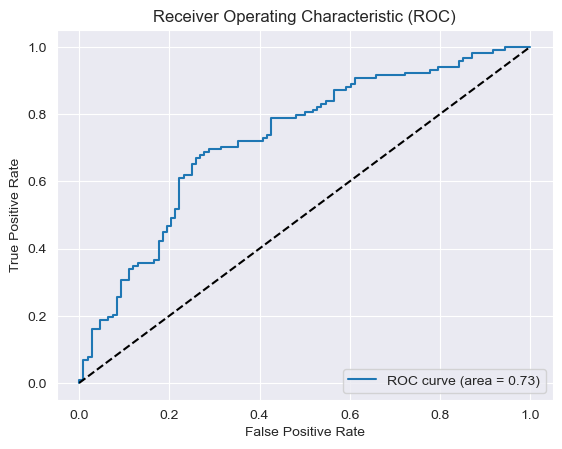

In [2161]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

roc_auc = roc_auc_score(y_test, best_logreg_model.predict_proba(X_test)[:,1])
fpr, tpr, thresholds = roc_curve(y_test, best_logreg_model.predict_proba(X_test)[:,1])

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

In [2162]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Step 1: Set up the Random Forest model
rf = RandomForestClassifier(random_state=0)

# Step 2: Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples required at each leaf node
    'bootstrap': [True, False]  # Whether bootstrap samples are used when building trees
}

# Step 3: Set up GridSearchCV with cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Step 4: Fit the grid search model on your training data
grid_search.fit(X_train, y_train)

# Step 5: Print the best parameters and best score
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-validation Score: {grid_search.best_score_}")

# Step 6: Use the best model to make predictions
best_rf_model = grid_search.best_estimator_

# Step 7: Evaluate the model on the test set
y_pred = best_rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy: {test_accuracy:.4f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Hyperparameters: {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-validation Score: 0.6556230816451811
Test Set Accuracy: 0.7080


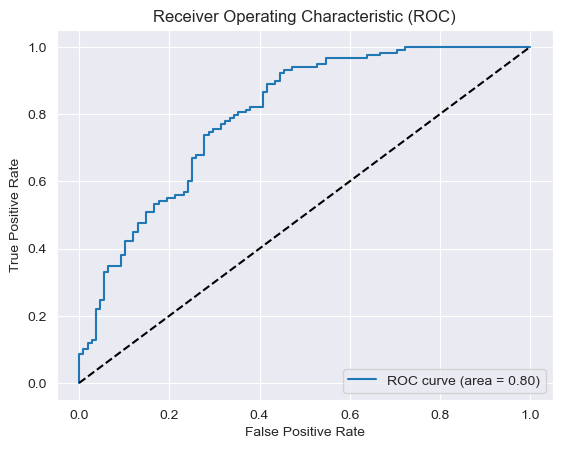

In [2163]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

roc_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:,1])
fpr, tpr, thresholds = roc_curve(y_test, best_rf_model.predict_proba(X_test)[:,1])

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()
